In [2]:
!pip install pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 89.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 81.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 73.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]9/10 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot theme for clear visualizations
sns.set_theme(style="whitegrid")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using the relative path
# The '../' tells the code to move up one folder from 'notebooks' into the root, 
# then into the 'data' folder.
file_path = '../data/Cleaned_Data_Project1.csv'

# Load the data
df = pd.read_csv(file_path)

# Display the first 5 rows to confirm it loaded correctly
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
# Check for data types and missing values
df.info()

# Check for total number of missing entries
print("\nTotal Missing Values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB

Total Missing Values per column:
OrderID            0
Date               0
CustomerID         0
Product   

In [5]:
# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Ensure numeric columns are strictly numeric
# (Already looks good, but this is a good safety habit)
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'])
df['TotalPrice'] = pd.to_numeric(df['TotalPrice'])

# Verify the changes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


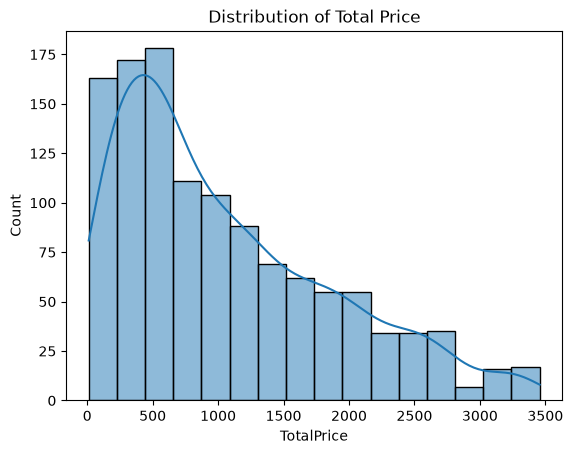

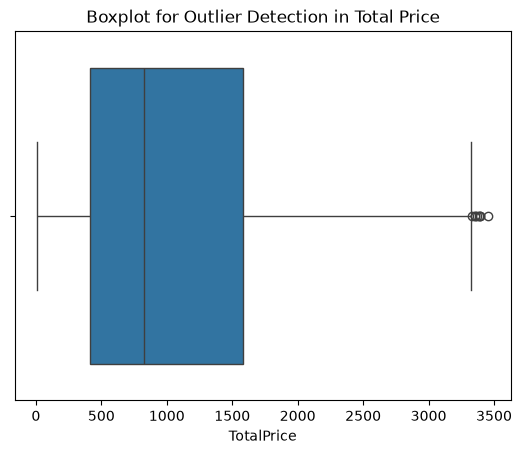

In [6]:
# Visualize the distribution of TotalPrice
sns.histplot(df['TotalPrice'], kde=True)
plt.title('Distribution of Total Price')
plt.show()

# Use a boxplot to identify outliers (the "Suspects")
sns.boxplot(x=df['TotalPrice'])
plt.title('Boxplot for Outlier Detection in Total Price')
plt.show()

In [7]:
# This provides the Min, Median, Q1, Q3, and Max
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300
std,1.407557,197.177146,819.856558
min,1.000000,11.390000,11.390000
25%,2.000000,186.062500,410.520000
50%,3.000000,364.210000,823.615000
75%,4.000000,521.570000,1578.475000
max,5.000000,699.930000,3456.400000


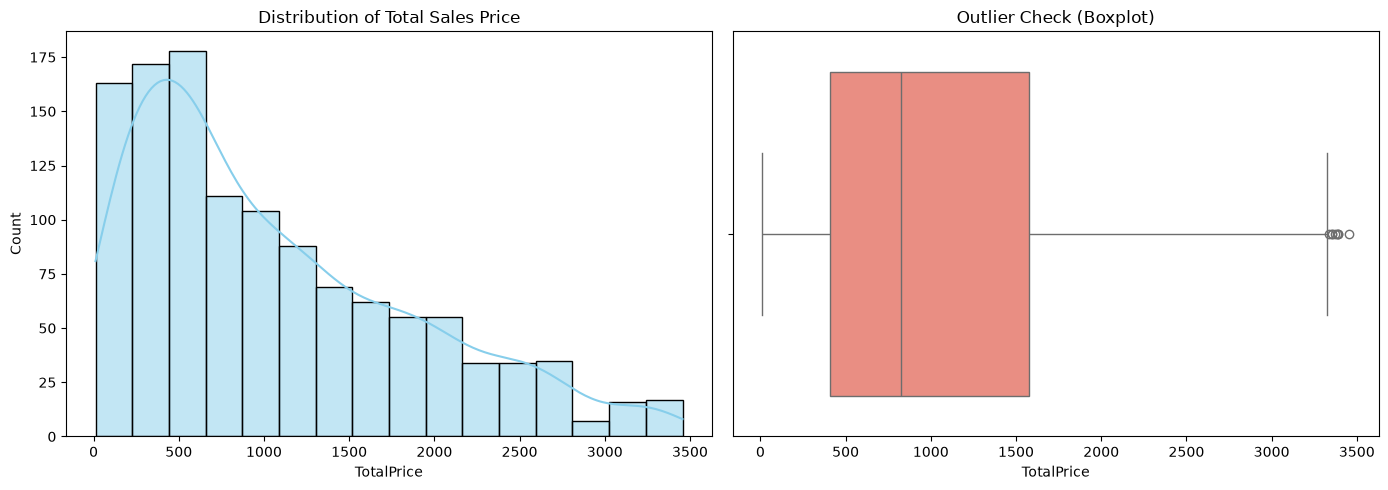

In [8]:
# Create a figure with two subplots: a distribution and a boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Distribution
sns.histplot(df['TotalPrice'], kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of Total Sales Price')

# Subplot 2: Boxplot (The Fingerprint of Variability)
sns.boxplot(x=df['TotalPrice'], ax=ax2, color='salmon')
ax2.set_title('Outlier Check (Boxplot)')

plt.tight_layout()
plt.show()

In [9]:
# Filter for the outliers (anything above ~3000 in your boxplot)
outliers = df[df['TotalPrice'] > 3000]
print(outliers[['OrderID', 'CustomerID', 'TotalPrice', 'Product']])

        OrderID CustomerID  TotalPrice  Product
10    ORD200010     C43443     3129.85   Tablet
86    ORD200086     C88205     3215.15  Printer
97    ORD200097     C15624     3097.60   Tablet
107   ORD200107     C16775     3353.75  Printer
221   ORD200221     C93473     3196.85   Tablet
241   ORD200241     C20817     3078.35    Chair
296   ORD200296     C48453     3194.00     Desk
326   ORD200326     C65986     3352.40   Laptop
328   ORD200328     C18404     3370.20   Tablet
361   ORD200361     C53464     3299.25  Printer
364   ORD200364     C85282     3143.70    Phone
367   ORD200367     C13108     3293.85   Laptop
450   ORD200450     C36408     3075.50  Monitor
463   ORD200463     C25276     3313.90   Laptop
469   ORD200469     C13877     3384.90    Chair
492   ORD200492     C39074     3032.60   Laptop
527   ORD200527     C27202     3267.35    Chair
540   ORD200540     C87281     3243.25   Laptop
632   ORD200632     C67260     3390.80   Laptop
633   ORD200633     C79533     3008.60  

High-Value Orders by Referral Source:
ReferralSource
Email        11
Instagram     7
Facebook      7
Referral      5
Google        4
Name: count, dtype: int64


/tmp/ipykernel_1893/2652148595.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=high_value_df, x='ReferralSource', palette='viridis')


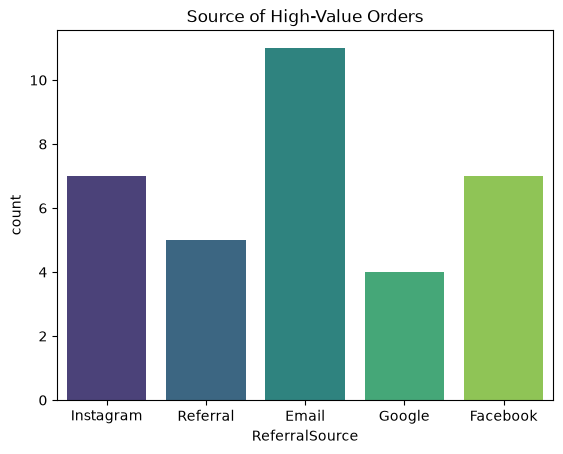

In [10]:
# Create a subset of high-value orders (using the outliers identified earlier)
high_value_df = df[df['TotalPrice'] > 3000]

# Count how many high-value orders come from each source
referral_counts = high_value_df['ReferralSource'].value_counts()

print("High-Value Orders by Referral Source:")
print(referral_counts)

# Visualize it
sns.countplot(data=high_value_df, x='ReferralSource', palette='viridis')
plt.title('Source of High-Value Orders')
plt.show()


High-Value Orders by Payment Method:
PaymentMethod
Gift Card      9
Online         7
Debit Card     7
Credit Card    6
Cash           5
Name: count, dtype: int64


/tmp/ipykernel_1893/278802396.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=high_value_df, x='PaymentMethod', palette='magma')


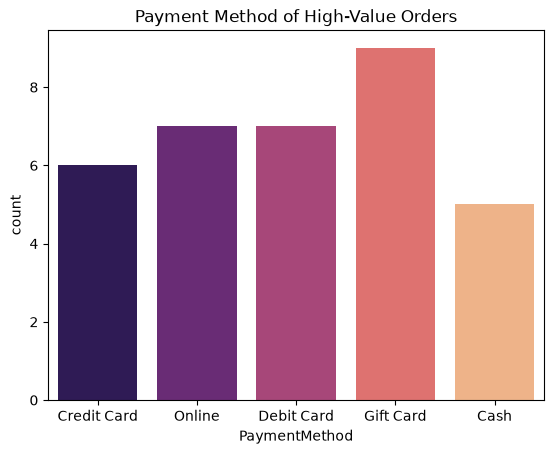

In [11]:
# Count how many high-value orders use each payment method
payment_counts = high_value_df['PaymentMethod'].value_counts()

print("\nHigh-Value Orders by Payment Method:")
print(payment_counts)

# Visualize it
sns.countplot(data=high_value_df, x='PaymentMethod', palette='magma')
plt.title('Payment Method of High-Value Orders')
plt.show()

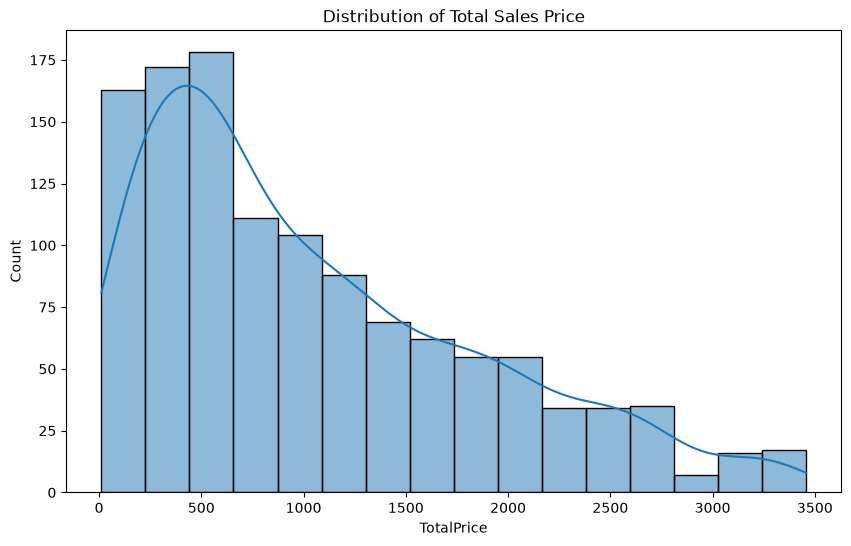

In [12]:
# 1. Generate the plot
plt.figure(figsize=(10, 6)) # Set a clear size
sns.histplot(df['TotalPrice'], kde=True)
plt.title('Distribution of Total Sales Price')

# 2. Save the plot to the reports folder
# 'bbox_inches="tight"' ensures labels aren't cut off in the saved file
plt.savefig('../reports/sales_distribution.png', bbox_inches='tight')

# 3. Display the plot in the notebook
plt.show()

### Key Visualizations
![Sales Distribution](reports/sales_distribution.png)